# EDA - Dataset
Análise exploratória completa dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
print(df.shape)
df.head()

(548, 3)


,id,text,label
0,002-0.cha,the scene is in the kitchen the mother is wipi...,0
1,002-1.cha,oh i see the sink is running over i see the st...,0
2,002-2.cha,um a boy and a girl are in the kitchen with th...,0
3,002-3.cha,okay it was summertime and mother and the chil...,0
4,006-2.cha,clears throat wait un til i put my glasses on ...,0


## Informações gerais

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      548 non-null    object
 1   text    548 non-null    object
 2   label   548 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 13.0+ KB


In [3]:
df.describe(include="all")

,id,text,label
count,548,548,548.000000
unique,548,544,NaN
top,002-0.cha,okay um you mean drying dishes uh overflowing ...,NaN
freq,1,2,NaN
mean,NaN,NaN,0.558394
std,NaN,NaN,0.497032
min,NaN,NaN,0.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,1.000000
75%,NaN,NaN,1.000000


## Distribuição das classes

In [4]:
df["label"].value_counts()

label
1    306
0    242
Name: count, dtype: int64

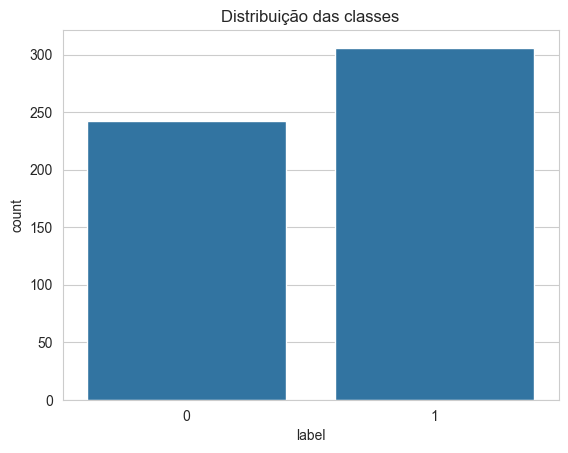

In [5]:
sns.countplot(x="label", data=df)
plt.title("Distribuição das classes")
plt.show()

## Tamanho dos textos

In [6]:
df["num_words"] = df["text"].apply(lambda x: len(x.split()))
df["num_chars"] = df["text"].apply(len)

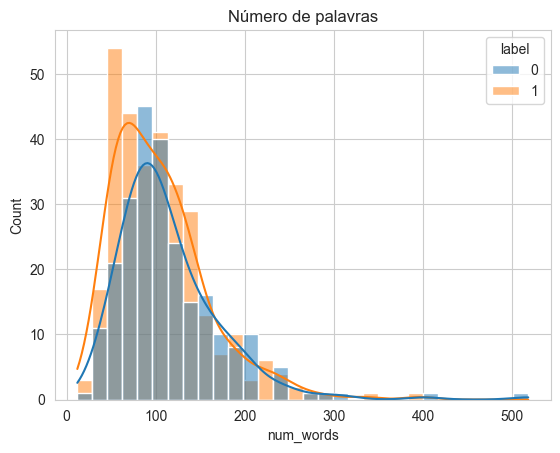

In [7]:
sns.histplot(data=df, x="num_words", hue="label", bins=30, kde=True)
plt.title("Número de palavras")
plt.show()

## Diversidade lexical

In [8]:
def lexical_diversity(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

df["lexical_diversity"] = df["text"].apply(lexical_diversity)

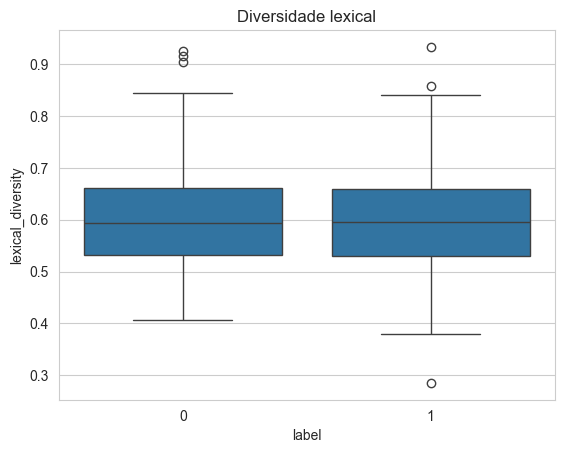

In [9]:
sns.boxplot(x="label", y="lexical_diversity", data=df)
plt.title("Diversidade lexical")
plt.show()

## Hesitações

In [10]:
def count_hesitations(text):
    hesitations = ["uh", "um", "ah", "er"]
    return sum(text.count(h) for h in hesitations)

df["hesitations"] = df["text"].apply(count_hesitations)

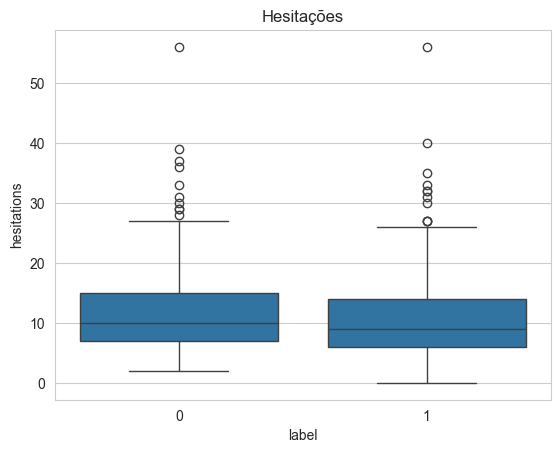

In [11]:
sns.boxplot(x="label", y="hesitations", data=df)
plt.title("Hesitações")
plt.show()

## Tamanho médio das palavras

In [12]:
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(w) for w in words])

df["avg_word_length"] = df["text"].apply(avg_word_length)

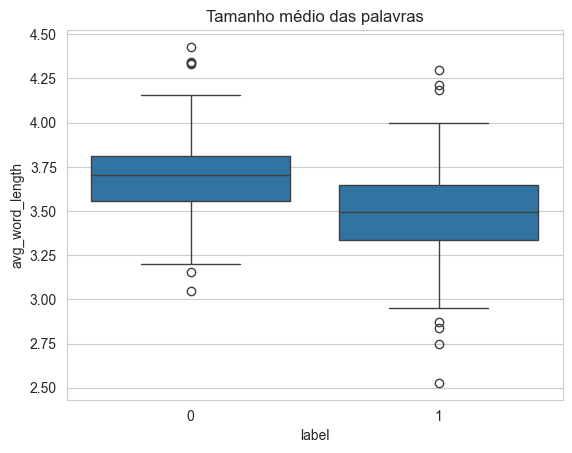

In [13]:
sns.boxplot(x="label", y="avg_word_length", data=df)
plt.title("Tamanho médio das palavras")
plt.show()

## Correlação

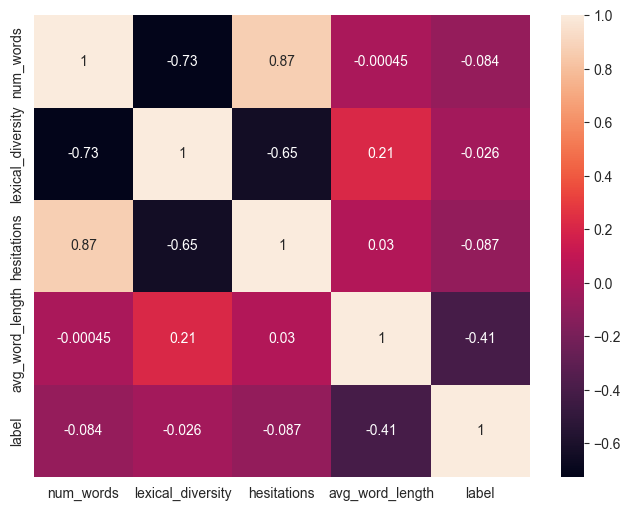

In [14]:
features = ["num_words", "lexical_diversity", "hesitations", "avg_word_length"]

corr = df[features + ["label"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

# Conclusões do dataset (análise completa)
🧱 1. Qualidade dos dados

Dataset com 548 amostras, sem valores nulos

Estrutura simples e adequada (id, text, label)

Pouca duplicidade → dados confiáveis

👉 ✔ Dataset pronto para modelagem

⚖️ 2. Balanceamento das classes

Classe 1 (demência): 306

Classe 0 (controle): 242

➡️ Levemente desbalanceado, mas aceitável

👉 ✔ Não precisa de técnicas complexas (SMOTE etc.)

📏 3. Tamanho dos textos

Distribuição assimétrica (long tail)

Maioria entre ~50 e 150 palavras

Alguns outliers grandes

👉 ⚠️ Implicações:

Pode impactar modelos simples

TF-IDF / normalização ajudam bastante

🧠 4. Sinais linguísticos (INSIGHT PRINCIPAL)

Aqui está o mais importante 👇

🔹 Diversidade lexical

Muito semelhante entre classes

Pequena variação

👉 ❌ Não é uma feature forte isoladamente

🔹 Hesitações (muito importante)

Distribuição maior na classe de demência

Mais variabilidade

👉 ✔ Feature promissora
👉 Pode capturar deterioração cognitiva

🔹 Tamanho médio das palavras

Classe controle → palavras ligeiramente maiores

Classe demência → palavras mais curtas

👉 ✔ Sinal linguístico relevante (simplificação da linguagem)

🔗 5. Correlações

num_words ↔ hesitations → alta correlação (0.87)

lexical_diversity ↔ num_words → negativa forte (-0.73)

label → baixa correlação com features isoladas

👉 🔥 Interpretação crítica:

Nenhuma feature sozinha resolve

O poder está na combinação delas

🧠 Conclusão geral (a mais importante)

👉 O problema não é linearmente separável com poucas features simples

Isso significa:

❌ Evite:

Regressão linear pura

Features isoladas

✅ Use:

Bag of Words / TF-IDF (principal)

Combinação com features linguísticas

Modelos mais robustos (LogReg com regularização, SVM, etc.)